# Neuron sim

In [28]:
from neuron import h
import neuron
import numpy as np
import pandas as pd
from scipy import stats as st
from scipy import signal as ss

import matplotlib.pyplot as plt
import os

In [29]:

###################### Load and organize Excel file ################################
circuit_params = {}

#Import Excel file
circuit_params = pd.read_excel('Circuit_param.xls', sheet_name = None, index_col = 0)

#Get cell names and import biophys
cell_names = [i for i in circuit_params['conn_probs'].axes[0]]

#  **``LFPy``** rand **``NetPyNE``**

In [30]:
circuit_params['SING_CELL_PARAM']

,HL23PYR,HL23SST,HL23PV,HL23VIP
GOU,0.000028,0.000030,0.000280,0.000066
norm_tonic,0.000938,0.000938,0.000938,0.000938
drug_tonic,0.001352,0.001030,0.001091,0.000938
apic_tonic,0.000938,0.000938,0.000938,0.000938
drug_apic_tonic,0.001352,0.001030,0.001091,0.000938
cell_num,2.000000,2.000000,2.000000,2.000000
rotate_x,3.000000,1.770000,6.000000,-1.570000
rotate_y,4.000000,2.770000,7.000000,3.570000


In [31]:
SPIKES = np.load("Circuit_output/SPIKES_Seed1234.npy", allow_pickle=True)

In [32]:
VOLTAGES = np.load("Circuit_output/VOLTAGES_Seed1234.npy", allow_pickle=True)

In [33]:
import pickle as pkl

with open("Circuit_output/v1_batch1_data.pkl", "rb") as f:
    data = pkl.load(f)

print("Loaded data type:", type(data))
if hasattr(data, "keys"):
    print("Keys:", list(data.keys()))
else:
    print("Data len:", len(data))

Loaded data type: <class 'dict'>
Keys: ['netpyne_version', 'netpyne_changeset', 'net', 'simConfig', 'simData']


In [34]:
data['simData']['V_soma'].keys()

dict_keys(['cell_0', 'cell_1', 'cell_2', 'cell_3', 'cell_4', 'cell_5', 'cell_6', 'cell_7'])

In [35]:
# use existing data (plt already imported)
voltage_data = VOLTAGES.item()['volts']  # list-of-lists by population/cell
pop_names = cell_names  # ['HL23PYR', 'HL23SST', 'HL23PV', 'HL23VIP']

# time axis by sample index (if no explicit dt available)
n_samples = len(voltage_data[0][0])
t = np.arange(0, 100000, 100000/n_samples)

cells = ["cell_"+str(i) for i in range(0,8)]
# fig = plt.figure(figsize=(24, 12))
# ii = 0
# for i in range(4):
#     for j in range(10):
#         plt.subplot(4,10, ii+1)
#         plt.plot(t[: len(np.asarray(voltage_data[0][0]))], np.asarray(voltage_data[i][j]), label="LFPy", color='blue')
#         plt.plot(data['simData']['t'], data['simData']['V_soma'][cells[ii]], label="NetPYNE", color='k', alpha = 0.5, linewidth=3)
#         ii = ii + 1
#         plt.ylabel('V (mV)')
#         plt.xlim(0, 200.0)
#         # plt.xlim(42, 46.0)
#         # plt.ylim(-84, -70)
#         plt.legend()
#         plt.grid(True)
#         if i == 3:
#             plt.xlabel('time (ms)')
#         # if i == 0:
#         #     plt.ylim(-75, -70)
# plt.show()



 	 POP: 0
mean PSPs: Exc-Exc -> LFPy: 4.19 mV (12011) 	 	 NetPyNE: 4.173465 mV (12080)
mean PSPs: Exc-Exc -> LFPy: 0.71 mV (65) 	 	 NetPyNE: 0.638655 mV (64)


 [-73.65089197 -73.65025393 -73.15922836 -73.71714563 -73.71714308
 -73.71714332 -73.70498502] [-73.65940659 -73.65868199 -73.06733641 -73.64818976 -73.64818346
 -73.64518667 -73.64818921] 






 	 POP: 1
mean PSPs: Exc-INH -> LFPy: 2.32 mV (43) 	 	 NetPyNE: 2.323977 mV (42)


 [-76.04177829 -76.16093945 -76.04178358 -76.01293932 -74.49845232] [-76.16316806 -76.05608769 -76.16304534 -76.13235165 -74.32510187] 




mean PSPs: Exc-INH -> LFPy: 2.30 mV (45) 	 	 NetPyNE: 2.327658 mV (44)


 [-76.01889433 -76.20640527 -76.0188992  -76.20640527 -76.17104462] [-76.19815095 -76.12001571 -76.19815296 -76.12001576 -76.09540226] 






 	 POP: 2
mean PSPs: Exc-INH -> LFPy: 3.03 mV (86) 	 	 NetPyNE: 3.448621 mV (87)


 [-79.93331608 -79.19470572 -80.10729976 -78.39951091 -82.49060217
 -82.51859334 -81.79042611 -78.52272369 -80.87591311] 

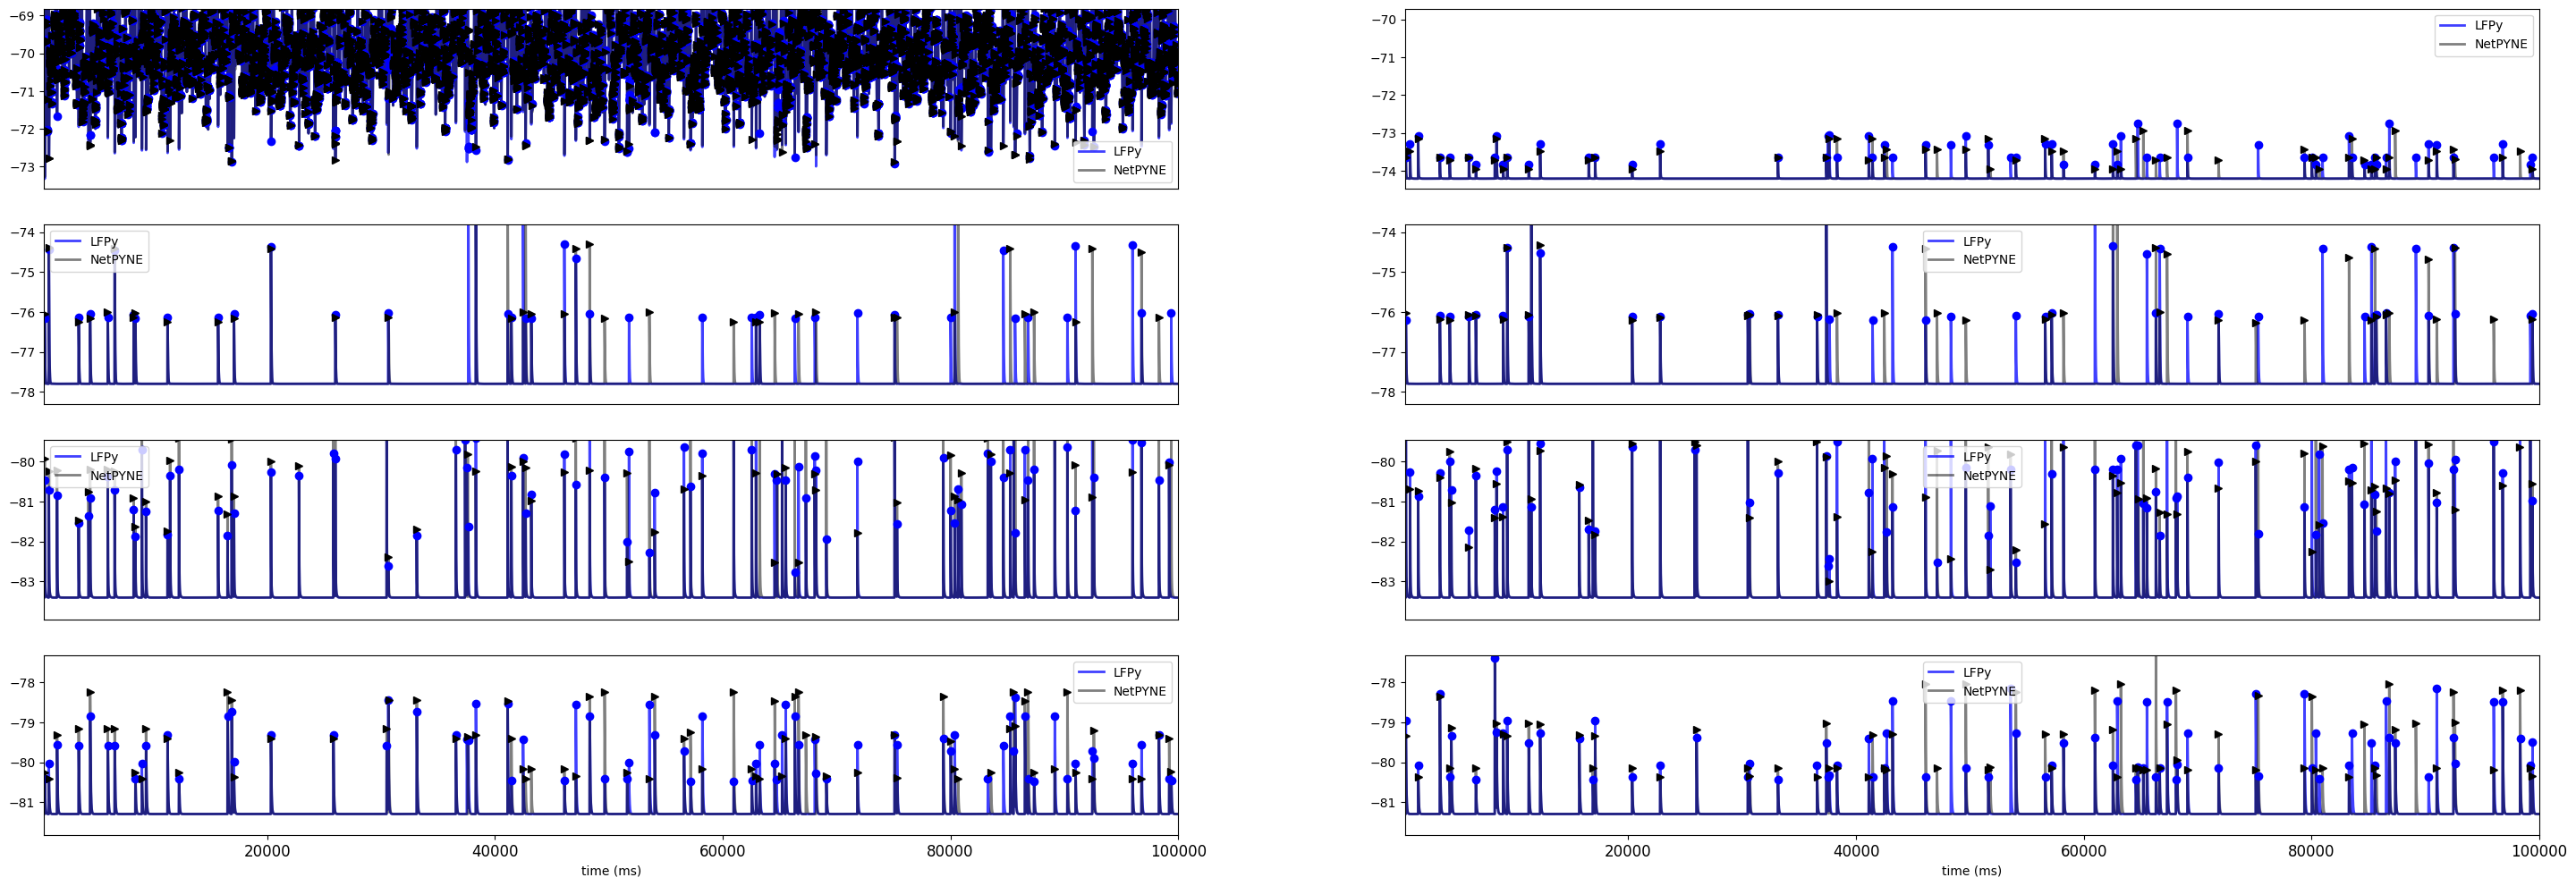

In [46]:
fig = plt.figure(figsize=(36, 12))

N = {}
L = {}
for i in range(4):
    N[i] = []
    L[i] = []

ii = 0
for i in range(4):
    print("\n\n \t POP:", i)
    for j in range(2):
        plt.subplot(4,2, ii+1)
        trace1 = np.asarray(voltage_data[i][j])[4000:100*40000]
        trace2 = data['simData']['V_soma'][cells[ii]][4000:100*40000]
        minV1 = np.min(list(trace1)+list(trace2))
        meanV1 = np.mean(list(trace1)+list(trace2))

        NetPyNEidx, NetPyNEpeak = ss.find_peaks(trace2, height=minV1+0.1)
        LFPyidx, LFPypeak = ss.find_peaks(trace1, height=minV1+0.1)
        
        plt.plot(t[: len(np.asarray(voltage_data[0][0]))], np.asarray(voltage_data[i][j]), label="LFPy", alpha = 0.75, linewidth=2, color='blue')
        plt.plot(data['simData']['t'], data['simData']['V_soma'][cells[ii]], label="NetPYNE", color='k', alpha = 0.5, linewidth=2)
        plt.plot(0.025*LFPyidx+100, LFPypeak['peak_heights'], 'o', color='blue')
        plt.plot(0.025*NetPyNEidx+100, NetPyNEpeak['peak_heights'], '>', color='k')
        if i == 0:
            plt.ylim(minV1-0.25, minV1+4.5)
            print("mean PSPs: Exc-Exc -> LFPy: %.2f mV (%d) \t \t NetPyNE: %.6f mV (%d)" % (LFPypeak['peak_heights'].mean()-minV1, len(LFPypeak['peak_heights']), NetPyNEpeak['peak_heights'].mean()-minV1,len(NetPyNEpeak['peak_heights'])))
        else:
            print("mean PSPs: Exc-INH -> LFPy: %.2f mV (%d) \t \t NetPyNE: %.6f mV (%d)" % (LFPypeak['peak_heights'].mean()-minV1, len(LFPypeak['peak_heights']), NetPyNEpeak['peak_heights'].mean()-minV1,len(NetPyNEpeak['peak_heights'])))
        if i > 0:
            plt.ylim(minV1-0.5, minV1+4.0)

        plt.xlim(400, 100000.0)
        plt.legend()

        if i == 3:
            plt.xticks(fontsize=12)
            plt.xlabel("time (ms)")
        else:
            plt.xticks([],fontsize=12)
            plt.xlabel("")
        
        ii = ii + 1
        if ii > 1:
            L[i] = L[i] + list(LFPypeak['peak_heights']-minV1)
            N[i] = N[i] + list(NetPyNEpeak['peak_heights']-minV1)
            print("\n\n",NetPyNEpeak['peak_heights'][::10], LFPypeak['peak_heights'][::10], "\n\n\n\n")




 	 POP: 0


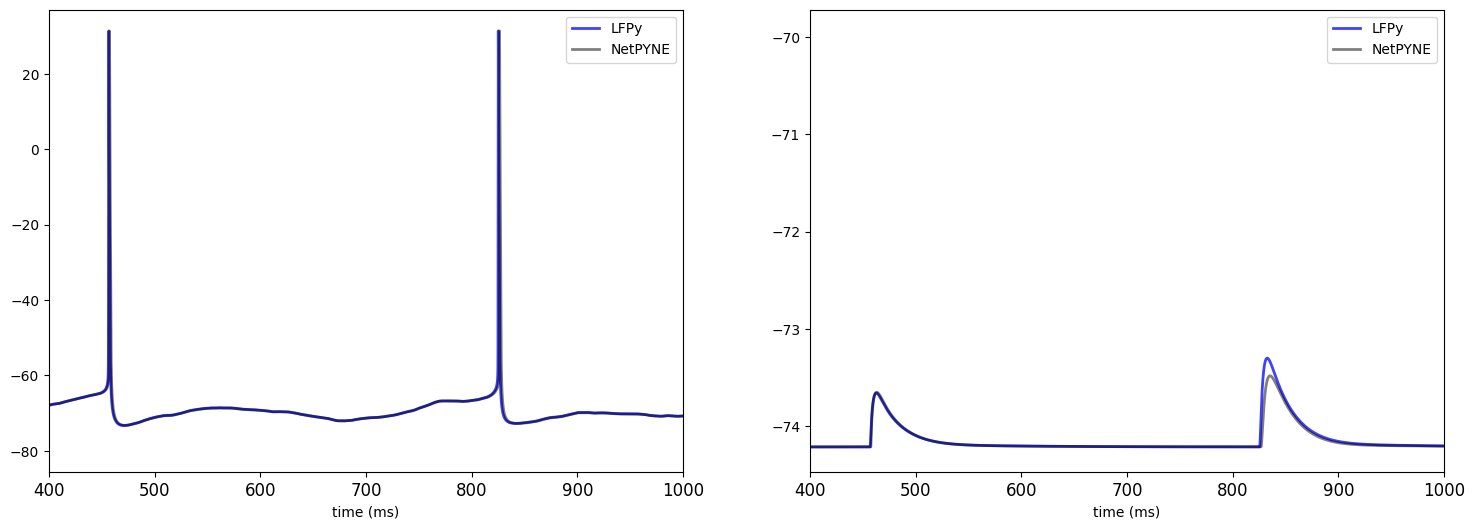

In [45]:
fig = plt.figure(figsize=(18, 6))
ii = 0
for i in range(1):
    print("\n\n \t POP:", i)
    for j in range(2):
        plt.subplot(1,2, ii+1)
        trace1 = np.asarray(voltage_data[i][j])[4000:10*40000]
        trace2 = data['simData']['V_soma'][cells[ii]][4000:10*40000]
        minV1 = np.min(list(trace1)+list(trace2))
        meanV1 = np.mean(list(trace1)+list(trace2))

        NetPyNEidx, NetPyNEpeak = ss.find_peaks(trace2, height=minV1+0.1)
        LFPyidx, LFPypeak = ss.find_peaks(trace1, height=minV1+0.1)
        
        plt.plot(t[: len(np.asarray(voltage_data[0][0]))], np.asarray(voltage_data[i][j]), label="LFPy", alpha = 0.75, linewidth=2, color='blue')
        plt.plot(data['simData']['t'], data['simData']['V_soma'][cells[ii]], label="NetPYNE", color='k', alpha = 0.5, linewidth=2)
        # plt.plot(t[: len(np.asarray(voltage_data[0][0]))], np.asarray(voltage_data[i][j]) - data['simData']['V_soma'][cells[ii]], label="NetPYNE", color='k', alpha = 0.5, linewidth=2)
        plt.xlim(400, 1000.0)
        # plt.ylim(-1, 1.0)
        plt.legend()

        if ii > 0:
            plt.ylim(minV1-0.25, minV1+4.5)
        if i < 3:
            plt.xticks(fontsize=12)
            plt.xlabel("time (ms)")
        else:
            plt.xticks([],fontsize=12)
            plt.xlabel("")
        ii = ii + 1

In [47]:
print("NetPyNE")
b , f = np.unique(data['simData']['spkid'], return_counts=True)
for i in range(0,50,10):
    print("%.2f ± %.2f " % (np.sum(f[i:i+10]),np.std(f[i:i+10])))

print("\nLFPy")
j = 0
for spk in SPIKES.all()['times']:
    L1 = []
    for i in range(len(spk)):
        if len(spk[i]) > 0:
            L1.append(len(spk[i]))
            j = j + 1
    print("%.2f ± %.2f " % (np.sum(L1),np.std(L1)))

NetPyNE
87.00 ± 0.00 
0.00 ± nan 
0.00 ± nan 
0.00 ± nan 
0.00 ± nan 

LFPy
88.00 ± 0.00 
0.00 ± nan 
0.00 ± nan 
0.00 ± nan 


In [48]:
# 1 - 10 sec
# LFPy 0.74 0.46 696 	 NetPyNE 0.88 0.55 693 		 PSP ratio LFPY/NetPyNE 0.84
# LFPy 3.37 1.93 553 	 NetPyNE 3.48 2.03 583 		 PSP ratio LFPY/NetPyNE 0.92
# LFPy 4.63 2.53 1004 	 NetPyNE 5.27 2.76 1040 	 PSP ratio LFPY/NetPyNE 0.85
# LFPy 3.22 2.09 821 	 NetPyNE 3.30 1.78 839 		 PSP ratio LFPY/NetPyNE 0.95
# 5 - 10 sec
# LFPy 0.66 0.36 417 	 NetPyNE 0.81 0.50 420 		 PSP ratio LFPY/NetPyNE 0.81
# LFPy 3.07 1.57 322 	 NetPyNE 2.99 1.46 307 		 PSP ratio LFPY/NetPyNE 1.08
# LFPy 4.33 1.88 601 	 NetPyNE 5.01 2.64 611 		 PSP ratio LFPY/NetPyNE 0.85
# LFPy 2.87 1.36 486 	 NetPyNE 3.39 1.88 514 		 PSP ratio LFPY/NetPyNE 0.80
# 8 - 10 sec
# LFPy 0.56 0.27 139 	 NetPyNE 0.70 0.38 132 		 PSP ratio LFPY/NetPyNE 0.84
# LFPy 2.50 1.21 95 	 NetPyNE 2.85 1.26 113 		 PSP ratio LFPY/NetPyNE 0.74
# LFPy 3.90 1.33 190 	 NetPyNE 4.35 1.82 187 		 PSP ratio LFPY/NetPyNE 0.91
# LFPy 2.35 1.02 156 	 NetPyNE 2.78 1.27 157 		 PSP ratio LFPY/NetPyNE 0.84

LFPy 0.71 0.30 65 	 NetPyNE 0.64 0.28 64 		 PSP ratio LFPY/NetPyNE 1.14
LFPy 2.31 1.05 88 	 NetPyNE 2.33 1.09 86 		 PSP ratio LFPY/NetPyNE 1.02
LFPy 3.11 1.04 174 	 NetPyNE 3.33 1.13 174 		 PSP ratio LFPY/NetPyNE 0.93
LFPy 1.72 0.69 151 	 NetPyNE 1.84 0.82 149 		 PSP ratio LFPY/NetPyNE 0.95


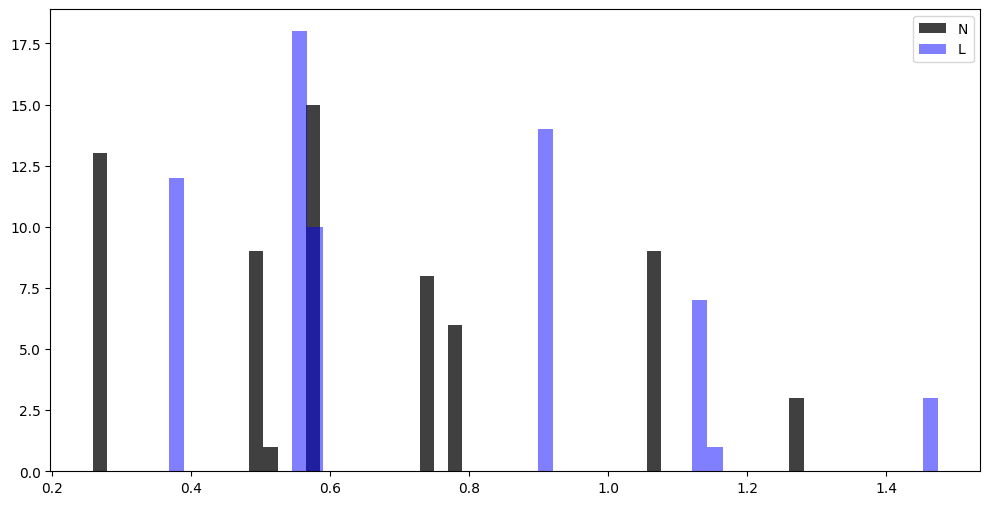

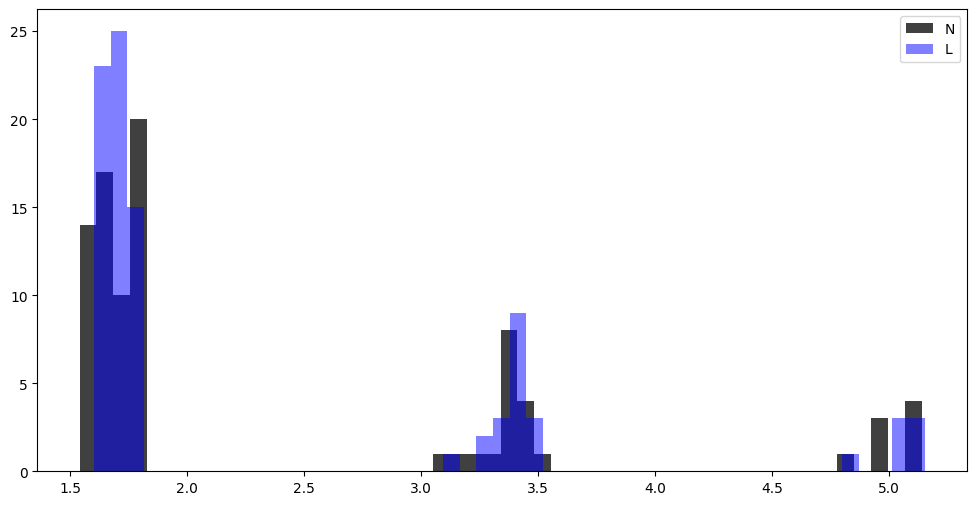

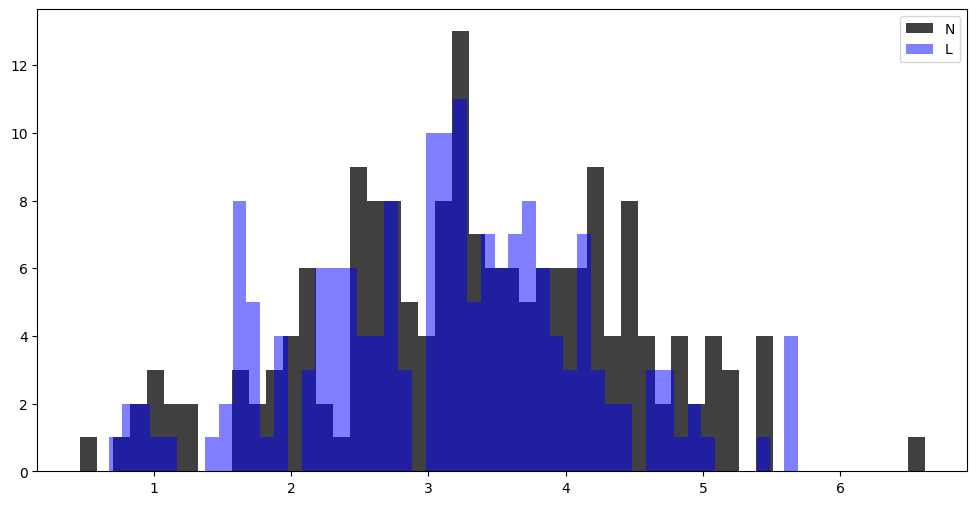

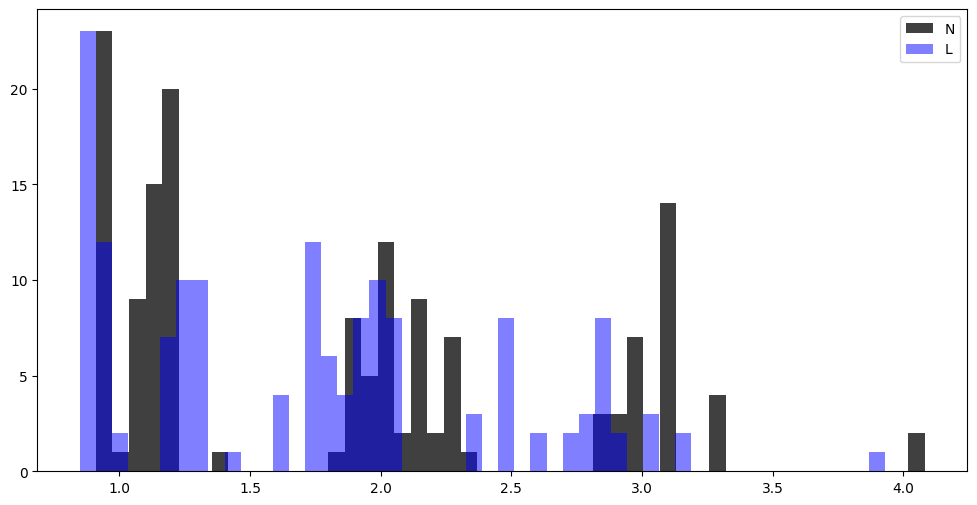

In [54]:
for i in range(4):
    fig = plt.figure(figsize=(12, 6))
    print("LFPy %.2f %.2f %d \t NetPyNE %.2f %.2f %d \t\t PSP ratio LFPY/NetPyNE %.2f" % (np.mean(L[i]), np.std(L[i]), len(L[i]), np.mean(N[i]), np.std(N[i]), len(N[i]),np.sum(L[i])/np.sum(N[i])))
    plt.hist(N[i],alpha=0.75, bins=50, label="N", color="k")
    # fig = plt.figure(figsize=(24, 6))
    plt.hist(L[i],alpha=0.5, bins=50, label="L", color="b")
    plt.legend()

{'HL23PYR': 0.088, 'HL23SST': 0.0, 'HL23PV': 0.0, 'HL23VIP': 0.0}

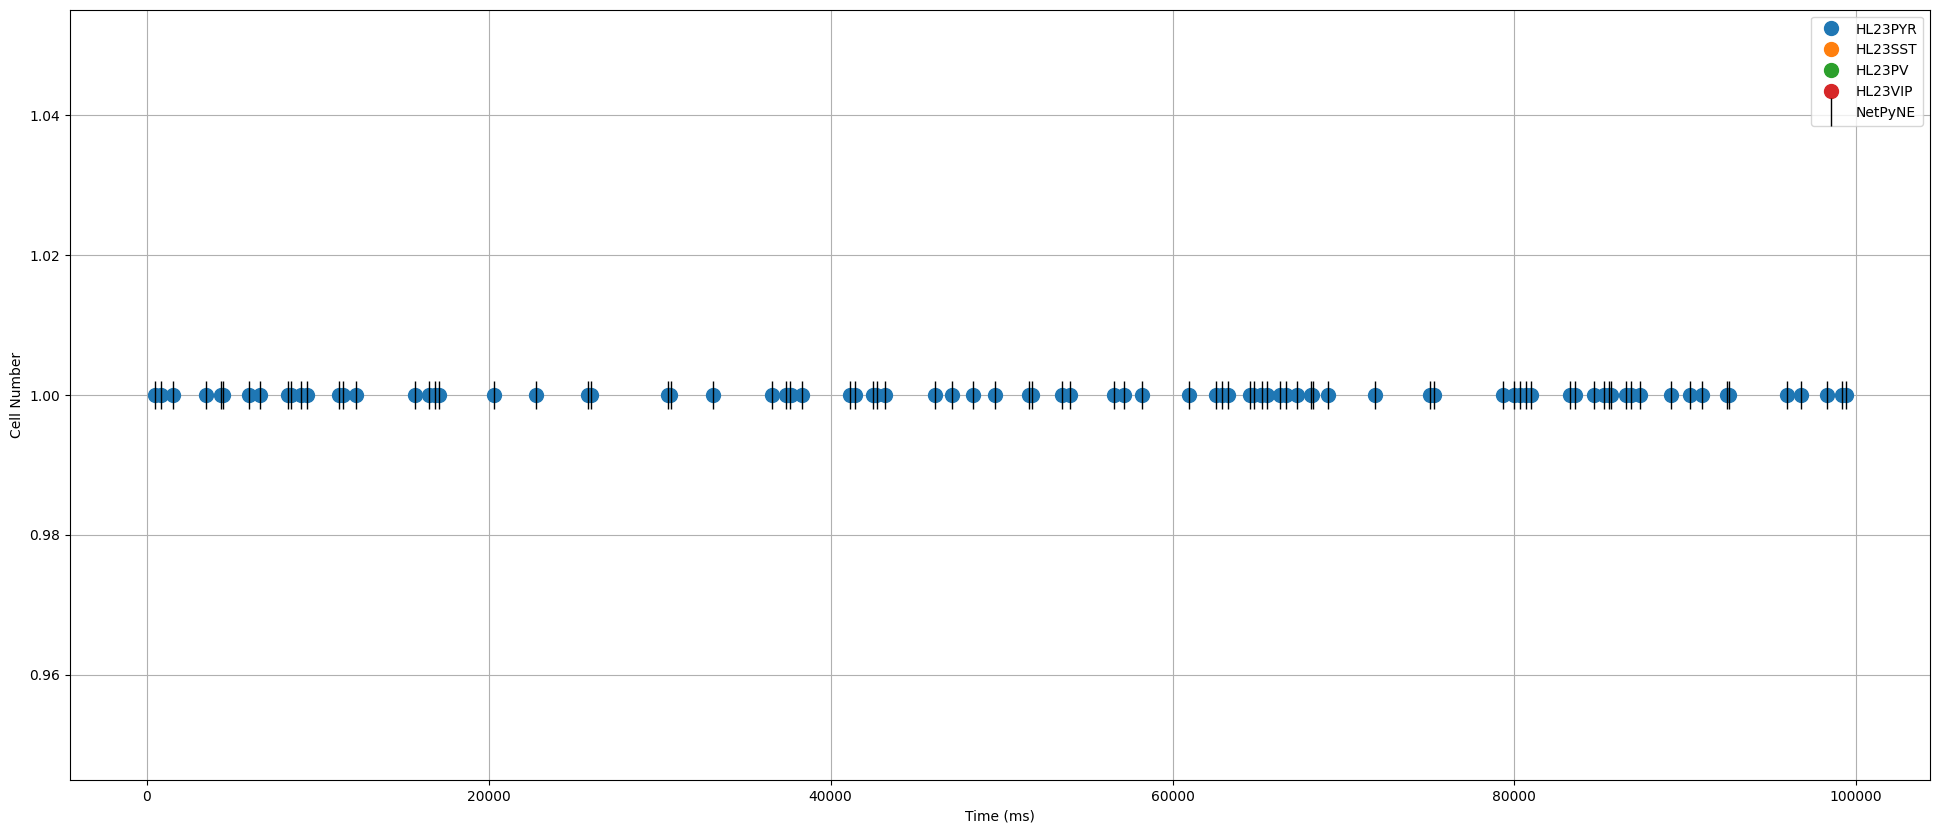

In [ ]:

def remove_axis_junk(ax, lines=['right', 'top']):
    """remove chosen lines from plotting axis"""
    for loc, spine in ax.spines.items():
        if loc in lines:
            spine.set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')

def plot_raster(SPIKES, cell_names):
        tinit = 0
        tend = 100000
        
        colors = ['dimgray', 'crimson', 'green', 'darkorange']
        pop_colors = {'HL23PYR':'dimgray', 'HL23SST':'crimson', 'HL23PV':'green', 'HL23VIP':'darkorange'}
        popnames = ['HL23PYR', 'HL23SST', 'HL23PV', 'HL23VIP']
        # pop_Number = {'HL23PYR': 800, 'HL23SST': 50, 'HL23PV': 70, 'HL23VIP': 80}
        pop_Number = {'HL23PYR': 10, 'HL23SST': 10, 'HL23PV': 10, 'HL23VIP': 10}
        firing_rate = {}
        # spike raster
        fig, ax = plt.subplots(1, 1, figsize=(24, 10))
        for name, spts, gids in zip(
                cell_names, SPIKES.item()['times'], SPIKES.item()['gids']):
            t = []
            g = []
            for spt, gid in zip(spts, gids):
                t = np.r_[t, spt]
                g = np.r_[g, np.zeros(spt.size) + gid]
            ax.plot(t[(t >= tinit) & (t < tend)], g[(t >= tinit) & (t < tend)]+1, 'o', ms=10, label=name)#, color=pop_colors[name])
            # print(name, (len(g[(t >= tinit) & (t < tend)]))/(((tend - tinit)/1000)*pop_Number[name]))
            firing_rate[name] = (len(g[(t >= tinit) & (t < tend)]))/(((tend - tinit)/1000)*pop_Number[name])
        # ax.set_ylim(415, -15)
        # ax.set_xlim(tinit + 250, tend - 250)
        ax.plot(data['simData']['spkt'], np.array(data['simData']['spkid'])+1, 'k|', ms=20, label="NetPyNE")
        # ax.set_xlim(40, 100)
        # ax.set_ylim(0, 13)
        # ax.set_xticks([4000, 4500, 5000])
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Cell Number')
        ax.legend(loc=1)
        ax.grid(True)

        return firing_rate

plot_raster(SPIKES, cell_names)

{'HL23PYR': 0.088, 'HL23SST': 0.0, 'HL23PV': 0.0, 'HL23VIP': 0.0}

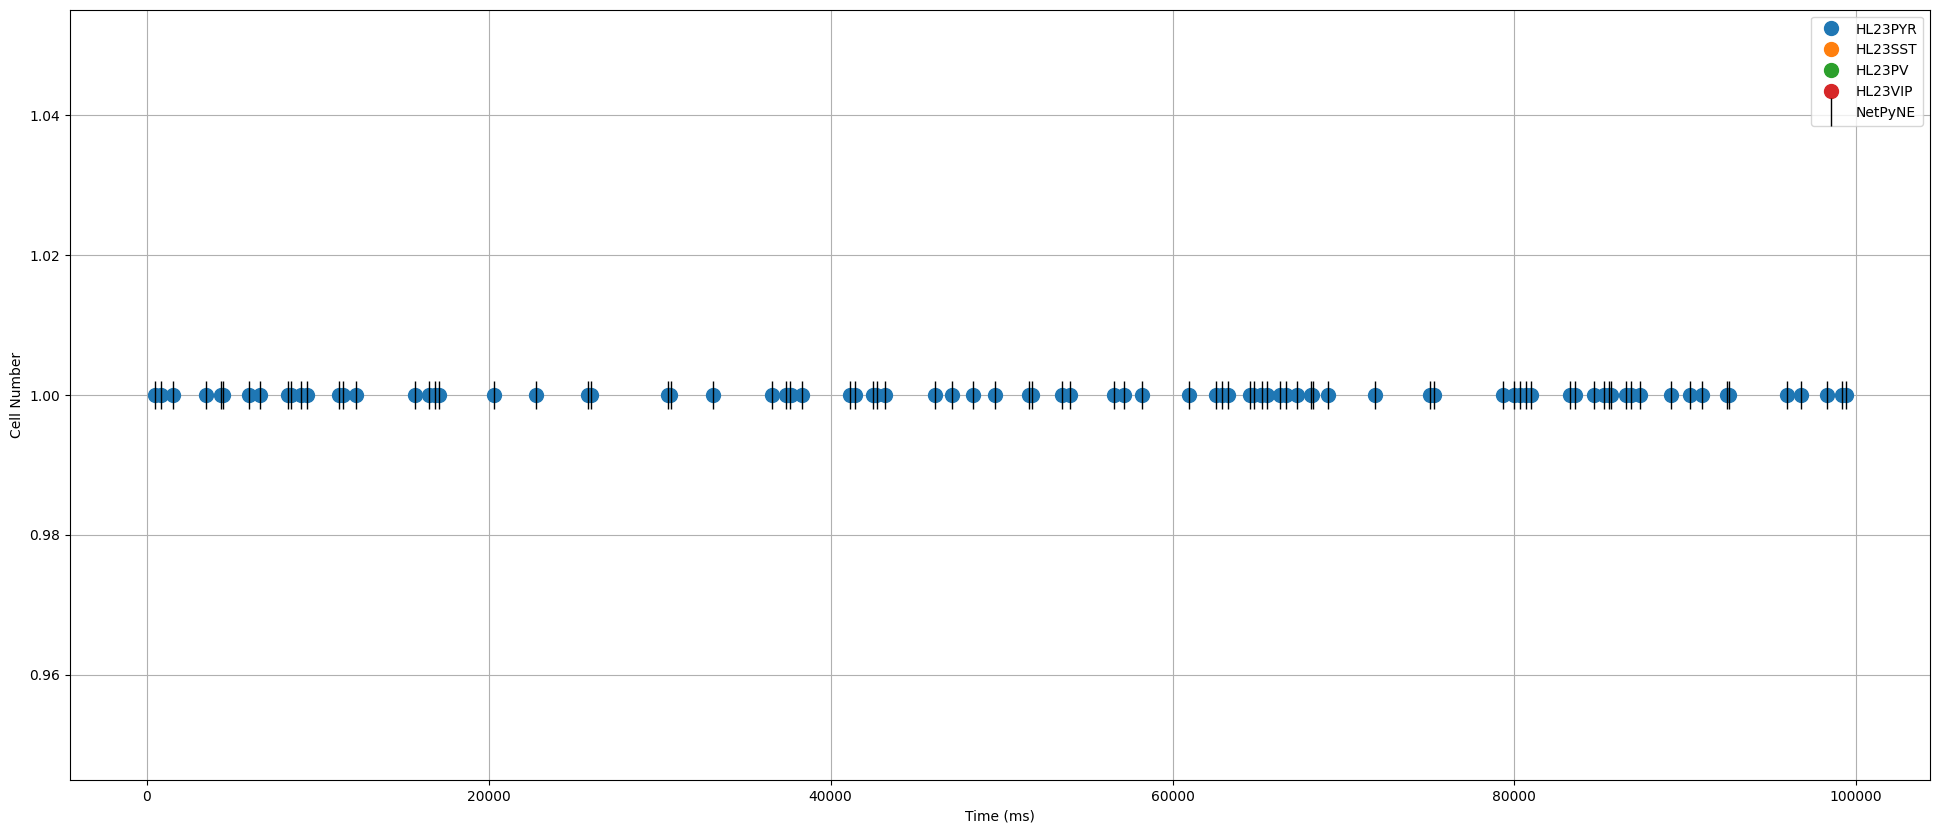

In [ ]:
plot_raster(SPIKES, cell_names)